# WildScan Bird-Sound Dataset — EDA

Exploratory look at the data behind the 50-genus bird-sound classifier.

**Source:** [Xeno-canto](https://xeno-canto.org) API v3 — quality **A/B** recordings
from the **United States + Canada**, ~100 per genus, balanced across member species,
filtered to **exact genus** (Xeno-canto's `gen:` is a prefix match, so this removes
contaminants like *Passerina* leaking into *Passer*).

Each recording is cleaned (32 kHz mono, DC removal, 150 Hz high-pass, peak-norm),
sliced into **5 s windows with 50% overlap**, ranked by **bird-band (1–11 kHz) SNR**
(top 12 kept), and turned into a **128×313 PCEN mel-spectrogram**.

*The raw `audio/` and `spectrograms/` are regenerable with
`python bird_classifier.py download && python bird_classifier.py preprocess`.*

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

rec  = pd.read_csv("recordings.csv")
spec = pd.read_csv("spectrograms.csv")
genera = json.load(open("genus_list.json"))["genera"]
common = {g["genus"]: g["common_label"] for g in genera}

print(f"Recordings:          {len(rec):,}")
print(f"Genera:              {rec.genus.nunique()}")
print(f"Spectrogram windows: {len(spec):,}")
print(f"Mean recordings/genus: {rec.genus.value_counts().mean():.1f}")
print(f"Mean windows/genus:    {spec.genus.value_counts().mean():.0f}")
rec[["genus","species","english_name","country","quality","type","length"]].head()

Recordings:          4,966
Genera:              50
Spectrogram windows: 31,586
Mean recordings/genus: 99.3
Mean windows/genus:    632


,genus,species,english_name,country,quality,type,length
0,Turdus,grayi,Clay-colored Thrush,United States,A,call,3:20
1,Turdus,migratorius,American Robin,Canada,B,"call, song",0:38
2,Turdus,grayi,Clay-colored Thrush,United States,A,song,1:15
3,Turdus,migratorius,American Robin,Canada,B,call,0:22
4,Turdus,migratorius,American Robin,Canada,B,song,1:01


## Class balance — recordings & windows per genus

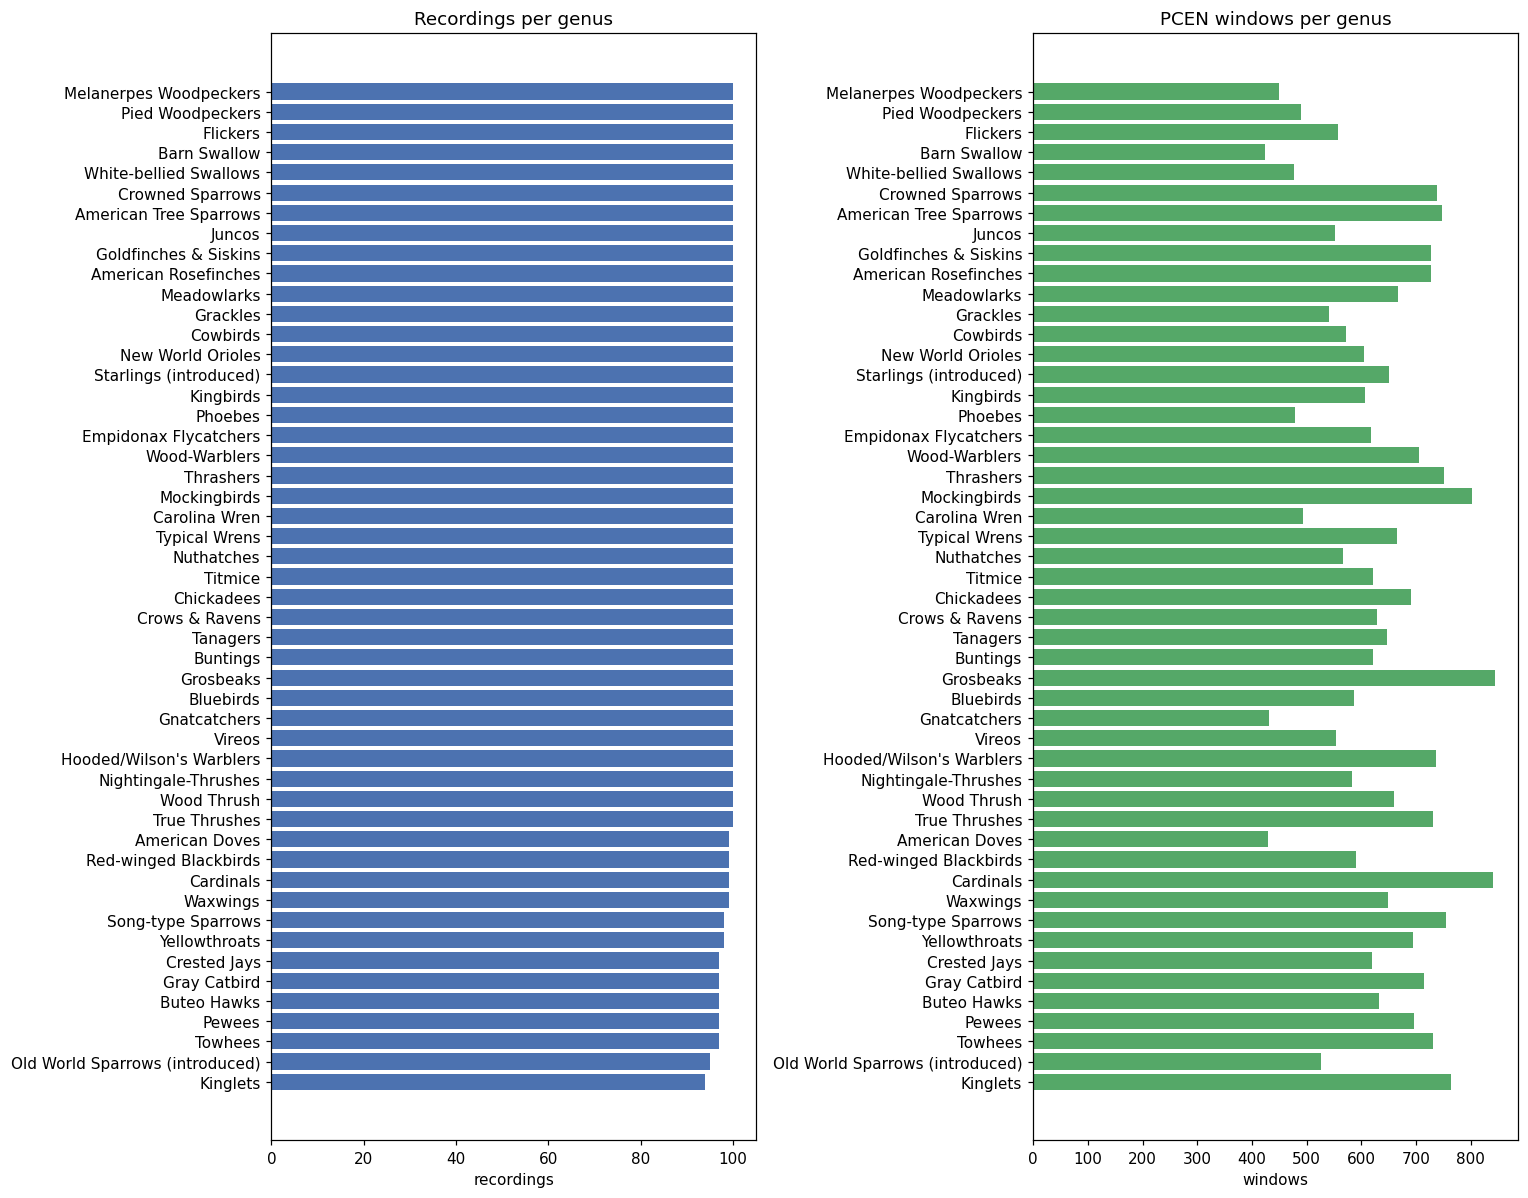

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 11))
vc = rec.genus.value_counts().sort_values()
ax[0].barh([common.get(g, g) for g in vc.index], vc.values, color="#4c72b0")
ax[0].set_title("Recordings per genus"); ax[0].set_xlabel("recordings")
wc = spec.genus.value_counts().reindex(vc.index)
ax[1].barh([common.get(g, g) for g in wc.index], wc.values, color="#55a868")
ax[1].set_title("PCEN windows per genus"); ax[1].set_xlabel("windows")
plt.tight_layout(); plt.show()

## Recording metadata — length, quality, country, type

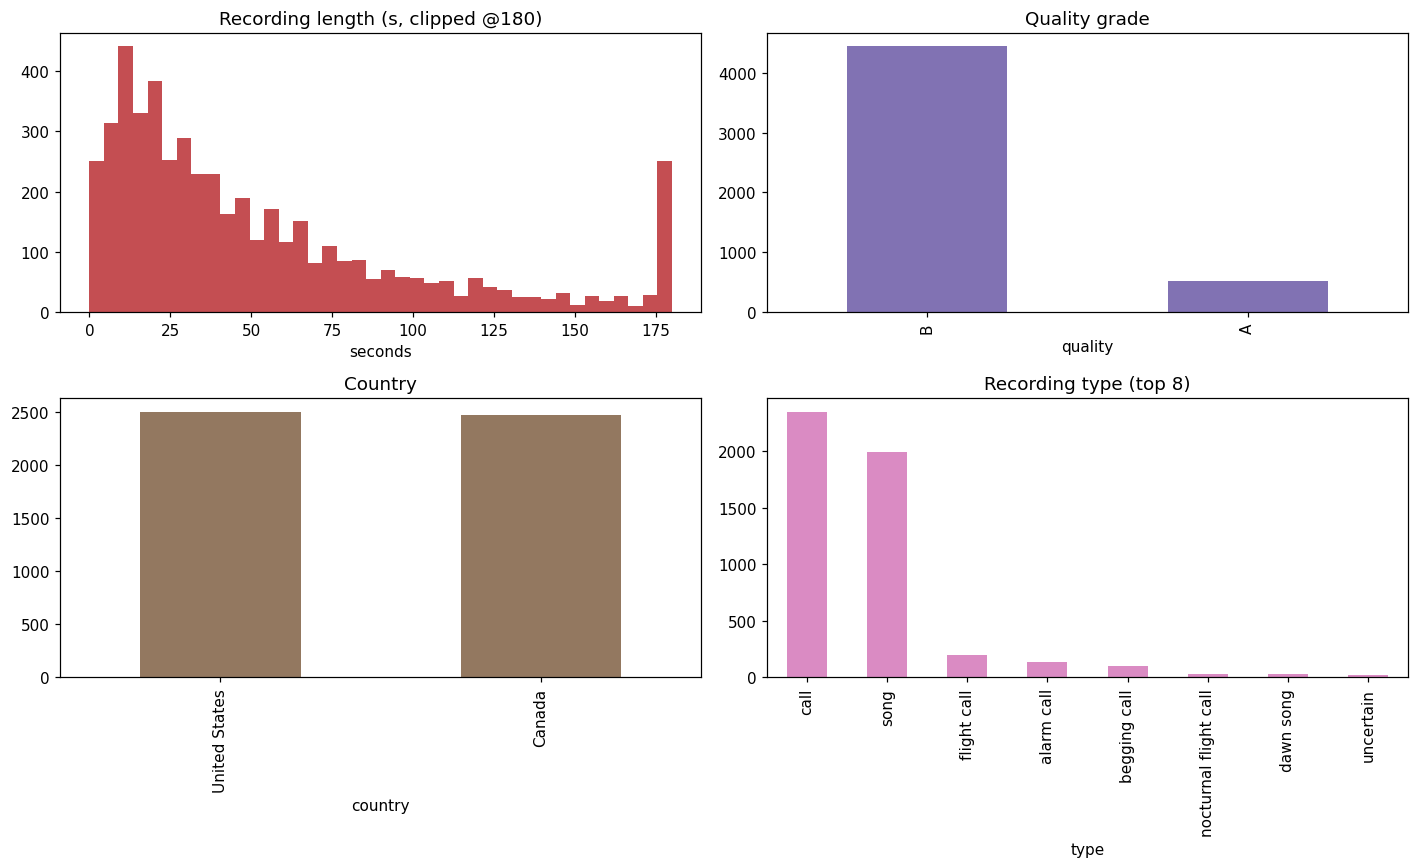

count    4966.0
mean       57.3
std        69.4
min         0.0
25%        16.0
50%        35.0
75%        72.0
max       870.0


In [3]:
def to_sec(s):
    try:
        p = [float(x) for x in str(s).split(":")]
        return p[0]*60+p[1] if len(p)==2 else (p[0]*3600+p[1]*60+p[2] if len(p)==3 else float(s))
    except Exception:
        return np.nan
rec["len_s"] = rec["length"].map(to_sec)

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
ax[0,0].hist(rec.len_s.dropna().clip(upper=180), bins=40, color="#c44e52")
ax[0,0].set_title("Recording length (s, clipped @180)"); ax[0,0].set_xlabel("seconds")
rec.quality.value_counts().plot.bar(ax=ax[0,1], color="#8172b3", title="Quality grade")
rec.country.value_counts().plot.bar(ax=ax[1,0], color="#937860", title="Country")
(rec["type"].astype(str).str.lower().str.split(",").str[0].str.strip()
    .value_counts().head(8).plot.bar(ax=ax[1,1], color="#da8bc3", title="Recording type (top 8)"))
plt.tight_layout(); plt.show()
print(rec.len_s.describe().round(1).to_string())

## Species diversity per genus

Genus-level labels intentionally fold multiple species together. Sampling is
balanced across the member species so one common species can't dominate.

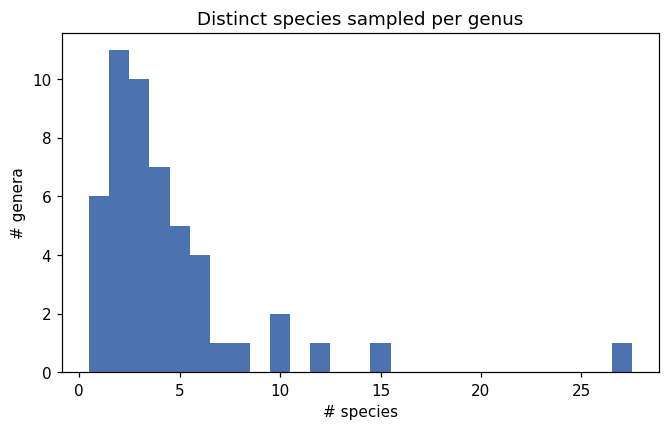

Most diverse genera:
genus
Setophaga    27
Vireo        15
Empidonax    12
Icterus      10
Buteo        10
Tyrannus      8
Toxostoma     7
Corvus        6


In [4]:
sp = rec.groupby("genus").species.nunique().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.hist(sp.values, bins=range(1, sp.max()+2), color="#4c72b0", align="left")
plt.title("Distinct species sampled per genus"); plt.xlabel("# species"); plt.ylabel("# genera"); plt.show()
print("Most diverse genera:"); print(sp.head(8).to_string())

## Example PCEN spectrograms (model input: 128 mel × 313 frames)

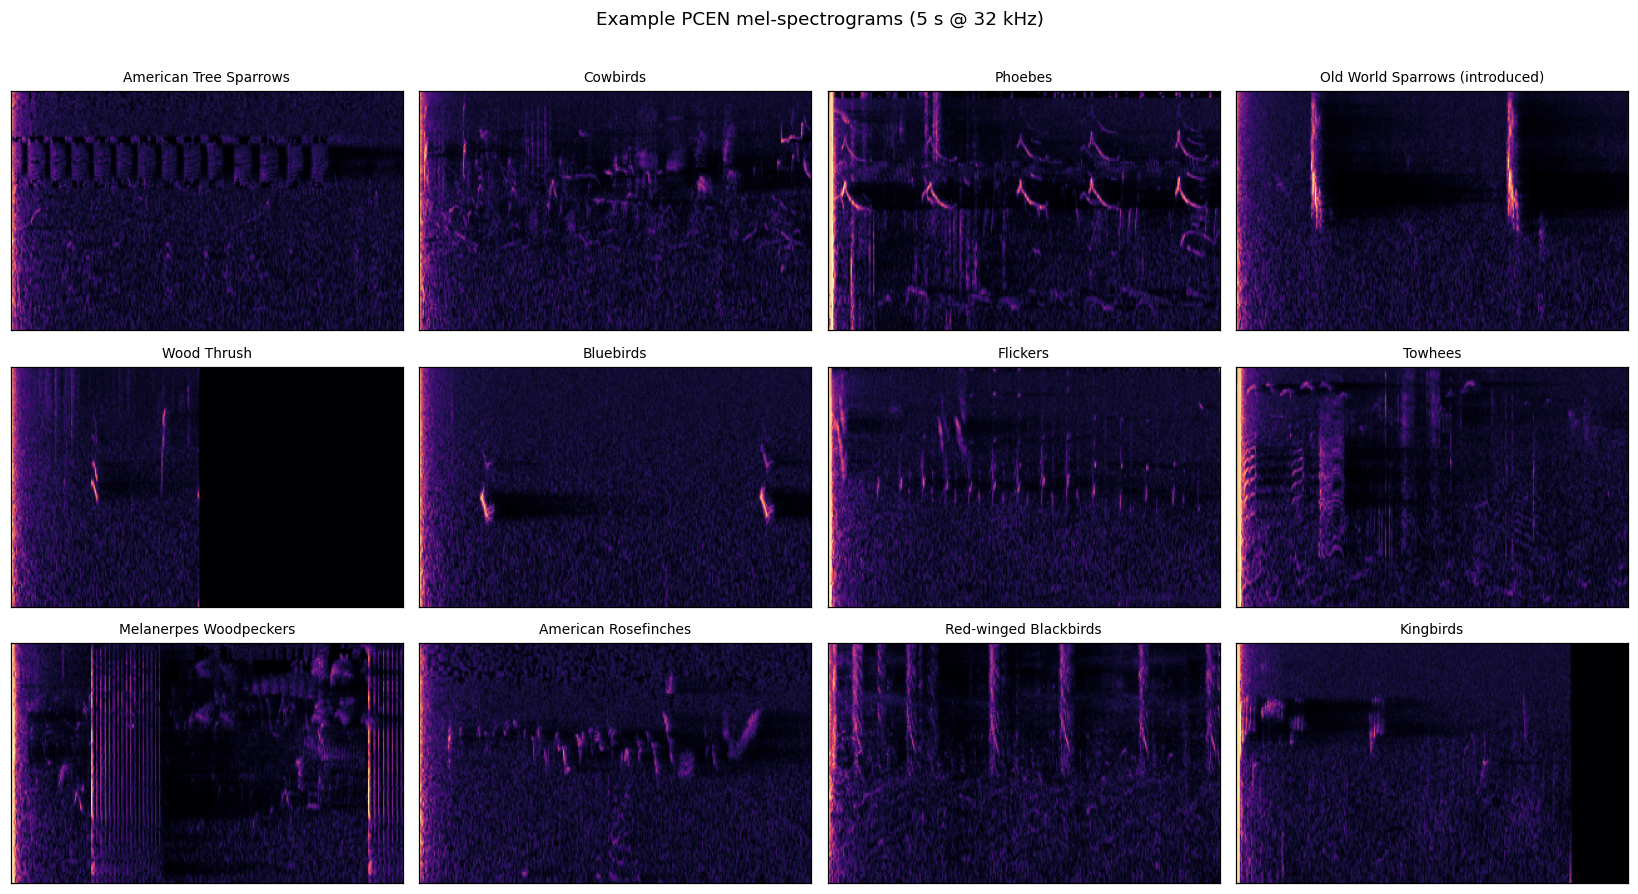

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
samp = list(spec.genus.drop_duplicates().sample(12, random_state=1))
for ax, g in zip(axes.flat, samp):
    arr = np.load(spec[spec.genus == g].iloc[0]["spec_path"])
    ax.imshow(arr, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(common.get(g, g), fontsize=9); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Example PCEN mel-spectrograms (5 s @ 32 kHz)", y=1.01); plt.tight_layout(); plt.show()

## A single recording — waveform → mel-spectrogram

/home/ubuntu/WildScan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


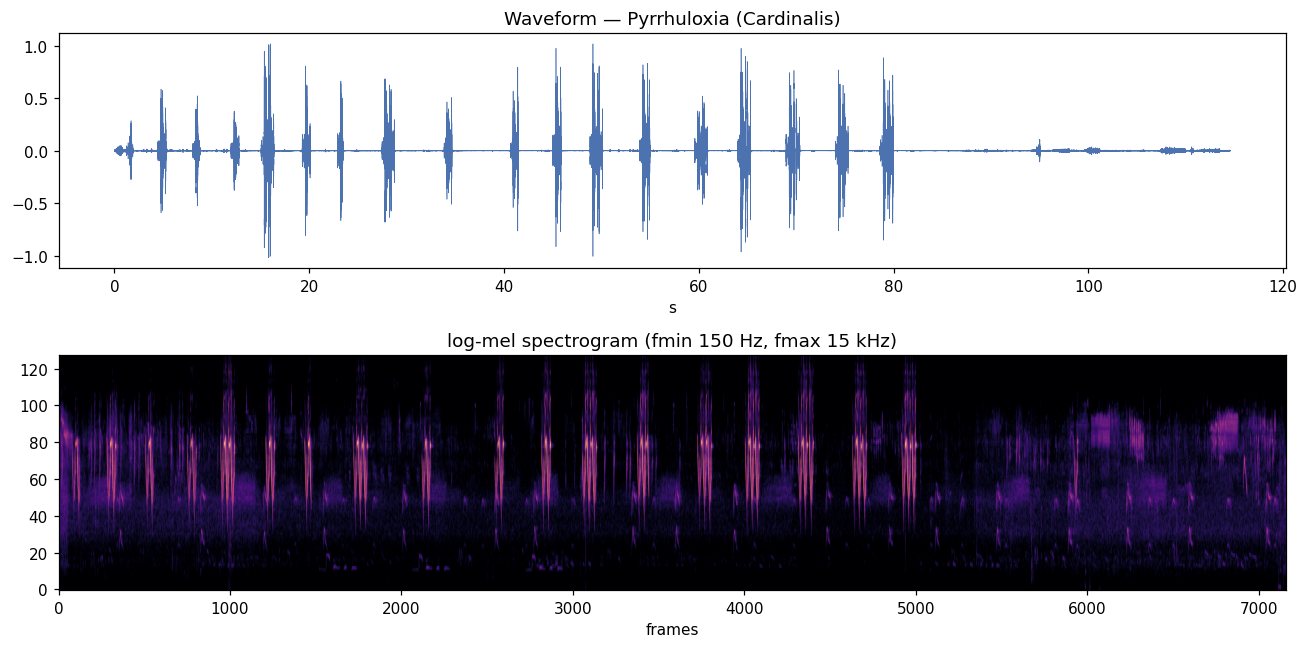

In [6]:
import librosa
ex = rec[rec.genus == "Cardinalis"].iloc[0]
y, sr = librosa.load(ex["audio_path"], sr=32000, mono=True)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(np.linspace(0, len(y)/sr, len(y)), y, lw=0.4, color="#4c72b0")
ax[0].set_title(f"Waveform — {ex['english_name']} ({ex['genus']})"); ax[0].set_xlabel("s")
S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmin=150, fmax=15000), ref=np.max)
ax[1].imshow(S, origin="lower", aspect="auto", cmap="magma")
ax[1].set_title("log-mel spectrogram (fmin 150 Hz, fmax 15 kHz)"); ax[1].set_xlabel("frames")
plt.tight_layout(); plt.show()